# Objective: compute the mean ET for LAI-aridity quantile bins

**Methods:**
- I masked out glaciated and snow covered land grid cells, where I define "glaciated" as glaciated land fraction greater than 0.8 and "snow covered" as time-mean snow cover fraction greater than 0.80. These criteria essentially mask out the same grid cells since glaciated land tends to have the highest time-mean snow cover fraction.
- I pooled grid cells across space and time for each ensemble member, selecting the 20-year period from 1995-2014 for a total of 240 months.
- I computed the quantile bin edges from the full ensemble pool to guarantee identical bin definitions across members. However, this means that the "quantiles" do not have exactly equal numbers of grid cells for each member.
- I placed all bare soil grid cells (LAI = 0) into the lowest quantile bin so it has a higher sample count than the other bins. However, I believe this is still better than the bare soil grid cells being distributed randomly across multiple lower quantile bins that all have LAI = 0.
- For each bin mean, I performed a two-sided t-test against a null hypothesis of 0 at alpha=0.05. Statistically insignificant bins are masked out. This assumes i.i.d. samples within each bin, which is a potentially faulty assumption if there is strong spatial or temporal correlation between bin samples. More complex techniques such as block bootstrapping or applying a spatial decorrelation adjustment to the effective degrees of freedom could be implemented for a more robust test.
- The radius of the circles is proportional to the number of grid cell samples in the bin.

In [1]:
import sys

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import xclimate as xclim

sys.path.insert(0, "/glade/u/home/bbuchovecky/projects/et_controls/binning")
from binning.ppe_2d_binning import compute_2d_bin_stats

%load_ext autoreload
%autoreload 2

In [2]:
client_cluster = xclim.create_dask_cluster(
    account='UWAS0155',
    nworkers=4,
    ncores=1,
    nmem='15GB',
    walltime='02:00:00',
)

account:  UWAS0155
nworkers: 4
ncores:   1
nmemory:  15GB
walltime: 02:00:00


/glade/work/bbuchovecky/miniforge3/envs/data-sci-py312/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 34661 instead
  warnings.warn(


{}

To view the dask dashboard
Run the following command in your local terminal:
> ssh -N -L 34661:128.117.211.162:34661 bbuchovecky@casper.hpc.ucar.edu
Open the following link in your local browser:
> http://localhost:34661/status


In [3]:
# xclim.close_dask_cluster(client_cluster)

# Load variables

In [4]:
tperiod = slice('1995-01', '2014-12')
grid = xclim.load_fhist_ppe_grid().compute()

In [5]:
variable_names = [
    "FSNO",
    "EFLX_LH_TOT", "TLAI",
    "FLDS", "FIRE", "FIRA",
    "FSDS", "FSR", "FSA",
    "PRECC", "PRECL",
    "FSH", "PS", "TSA", "RH2M", "U10",
]

# Load variables
fhist = {}
variables = []
for v in variable_names:
    print(v)
    key = f"{v}_month_1"
    fhist[key] = (
        xclim.load_fhist(key, keep_var_only=True)[v]
        .sel(time=tperiod)
        .reindex_like(grid, method="nearest", tolerance=1e-3)
        .chunk({'time': -1})
        .persist()
    )
    variables.append(key)

# Rename ET
fhist["ET_month_1"] = fhist["EFLX_LH_TOT_month_1"]
fhist.pop("EFLX_LH_TOT_month_1")

# Monthly net radiation at the surface, + down
#   Rn = (net SW) + (net LW) = (down SW - up SW) - (down LW - up LW)
#   Rn = FSDS - FSR + FLDS - FIRE
fhist["RN_month_1"] = fhist["FSDS_month_1"] - fhist["FSR_month_1"] + fhist["FLDS_month_1"] - fhist["FIRE_month_1"]
fhist["RN_month_1"] = fhist["RN_month_1"].rename("RN")
fhist["RN_month_1"].attrs = {
    "long_name": "net radiation at surface [+ down]",
    "description": "FSDS - FSR + FLDS - FIRE",
    "units": "W/m2",
}

# Climatological net radiation at the surface
fhist["RN_clim"] = fhist["RN_month_1"].weighted(fhist["RN_month_1"].time.dt.days_in_month).mean("time")
fhist["RN_clim"].attrs["time_mean"] = f"{tperiod.start} to {tperiod.stop}"

# Monthly precipitation rate (PRECC + PRECL)
fhist["PRECT_month_1"] = (fhist["PRECC_month_1"] + fhist["PRECL_month_1"]) * 1000 * 2.5e6
fhist["PRECT_month_1"] = xr.where(fhist["PRECT_month_1"] < 1e-3, 1e-3, fhist["PRECT_month_1"])
fhist["PRECT_month_1"].attrs["units"] = "W/m2"

# Climatological precipitation rate
fhist["PRECT_clim"] = fhist["PRECT_month_1"].weighted(fhist["PRECT_month_1"].time.dt.days_in_month).mean("time")
fhist["PRECT_clim"].attrs["time_mean"] = f"{tperiod.start} to {tperiod.stop}"

# Monthly Aridity Index
fhist["AI_month_1"] = fhist["RN_month_1"] / fhist["PRECT_month_1"]
fhist["AI_month_1"] = fhist["AI_month_1"].rename("AI")
fhist["AI_month_1"].attrs = {
    "long_name": "aridity index",
    "description": "Rn / (Lv * P)",
    "time_mean": f"{tperiod.start} to {tperiod.stop}"
}

# Climatological Aridity Index (AI = RN / PRECT)
fhist["AI_clim"] = fhist["RN_clim"] / fhist["PRECT_clim"]
fhist["AI_clim"] = fhist["AI_clim"].rename("AI")
fhist["AI_clim"].attrs = {
    "long_name": "aridity index",
    "description": "Rn / (Lv * P)",
    "time_mean": f"{tperiod.start} to {tperiod.stop}"
}

FSNO
EFLX_LH_TOT
TLAI
FLDS
FIRE
FIRA
FSDS
FSR
FSA
PRECC
PRECL
FSH
PS
TSA
RH2M
U10


# Mask variables

In [6]:
snow_pct_threshold = 80 / 100  # maximum allowable percent of snow cover on all months of the average year
nonglc_pct_threshold = 80      # maximum allowable percent of glaciated land for a NON-glaciated gridcell

fhist["FSNO_clim"] = fhist["FSNO_month_1"].weighted(fhist["FSNO_month_1"].time.dt.days_in_month).mean("time")
snow_mask = xr.where(fhist["FSNO_clim"].sel(member=0) > snow_pct_threshold, 0, 1)

nonglc_mask = grid.PCT_GLC < nonglc_pct_threshold
all_mask = snow_mask & nonglc_mask & (grid.LANDFRAC > 0)

In [7]:
fhist_masked = {}
for name, da in fhist.items():
    fhist_masked[name] = fhist[name].where(all_mask)

# Get most arid months

In [38]:
def compute_esat_empirical(temp_C):
    """Saturation vapor pressure from empirical form in Schefff & Frierson (2014)."""
    return 610.8 * np.exp((17.27 * temp_C) / (temp_C + 273.15))


def calc_pm_pet(SH, LH, T_a, RH, U, P_s):
    """
    SH : np.ndarray
        Sensible heat flux [W m-2]
    LH : np.ndarray
        Latent heat flux [W m-2]
    T_a : np.ndarray
        Near-surface air temperature [K]
    RH : np.ndarray
        Near-surface relative humidity [1]
    U : np.ndarray
        Near-surface wind speed [m s-1]
    P_s : np.ndarray
        Surface pressure [Pa]

    Scheff, J., & Frierson, D. M. W. (2014). Scaling Potential
    Evapotranspirationwith Greenhouse Warming. Journal of Climate,
    27(4), 1539-1558. https://doi.org/10.1175/JCLI-D-13-00233.1
    """

    # Constants
    L_v = 2.45e6  # [J kg-1]
    r_s = 40  # [s m-1], set to match Cook et al. (2014)
    epsilon = 0.622  # [1]
    c_p = 4182  # [J kg-1 K-1]
    R_v = 461  # [J kg-1 K-1]

    # Drag coefficient constants
    k = 0.41  # [1]
    h = 0.5  # [m], assumed vegetation height for alfalfa
    z_w = 10  # [m]
    z_h = 2  # [m]
    z_om = 0.123 * h  # [m]
    z_oh = 0.0123 * h  # [m]
    d = 0  # [m]

    C_H = (k * k) / (np.log((z_w - d) / z_om) * np.log((z_h - d) / z_oh))

    rho_a = 1.01 * P_s / R_v / T_a
    gamma = P_s * c_p / epsilon / L_v
    e_sat = compute_esat_empirical(T_a - 273.15)
    delta = L_v * e_sat / R_v / T_a / T_a

    numerator = (delta * (SH + LH)) + (rho_a * c_p * e_sat * (1 - RH) * C_H * U)
    denominator = delta + gamma * (1 + r_s * C_H * U)
    pet = numerator / denominator

    if isinstance(pet, xr.DataArray):
        pet = pet.rename("PET")
        pet.attrs = {
            "long_name": "Penman-Monteith potential evapotranspiration",
            "units": "W/m2",
        }

    return pet


def clim_max_month(x_clim, n_month):
    assert n_month % 2 == 1
    pad = n_month // 2

    # Pad with edge months to handle wraparound
    x_clim_padded = xr.concat(
        [
            x_clim.isel(month=slice(-pad, None)),  # Last month(s)
            x_clim,
            x_clim.isel(month=slice(0, pad)),  # First month(s)
        ],
        dim="month",
    )

    # Find center month of maximum rolling mean
    max_center_month = (
        x_clim_padded.rolling(month=n_month, center=True)
        .mean()
        .isel(month=slice(pad, -pad))  # remove padding
        .fillna(-np.inf)  # fill NaN with -inf so argmax doesn't fail
        .argmax(dim="month")
        + 1  # +1 to convert 0-indexed to 1-12
    )

    # Add metadata
    max_center_month = max_center_month.rename("X_max_clim")
    max_center_month.attrs = {
        "long_name": "center month of the climatological maximum of X [1=Jan, 12=Dec]",
        "description": f"climatological maximum is defined as the {n_month} adjacent months with the greatest climatological X",
    }

    return max_center_month


def clim_min_month(x_clim, n_month):
    assert n_month % 2 == 1
    pad = n_month // 2

    # Pad with edge months to handle wraparound
    x_clim_padded = xr.concat(
        [
            x_clim.isel(month=slice(-pad, None)),  # Last month(s)
            x_clim,
            x_clim.isel(month=slice(0, pad)),  # First month(s)
        ],
        dim="month",
    )

    # Find center month of minimum rolling mean
    min_center_month = (
        x_clim_padded.rolling(month=n_month, center=True)
        .mean()
        .isel(month=slice(pad, -pad))  # remove padding
        .fillna(np.inf)  # fill NaN with +inf so argin doesn't fail
        .argmin(dim="month")
        + 1  # +1 to convert 0-indexed to 1-12
    )

    # Add metadata
    min_center_month = min_center_month.rename("X_min_clim")
    min_center_month.attrs = {
        "long_name": "center month of the climatological minimum of X [1=Jan, 12=Dec]",
        "description": f"climatological minimum is defined as the {n_month} adjacent months with the lowest climatological X",
    }

    return min_center_month


def clim_subset_mean(da, center_month, n_month):
    """Compute annual mean of a variable over a group of adjacent months."""
    assert n_month % 2 == 1
    pad = n_month // 2

    # Compute distance from center month (handling wraparound: Dec->Jan)
    month_nums = xr.DataArray(
        data=np.arange(1, 13), dims=["month"], coords={"month": np.arange(1, 13)}
    )
    dist = ((month_nums - center_month + 6) % 12) - 6  # range: -6 to +5

    # Select months within +/-1 of center (the 3-month window)
    mask = np.abs(dist) <= pad

    def _process_year(yearly_data):
        """
        Compute the annual mean of a specified subset of months.

        yearly_data has dims: (time: 12, member: N, lat: M, lon: L)
        """
        # Extract month numbers for this year (1-12)
        months = yearly_data.time.dt.month

        # Get the mask values for these specific months
        mask_for_year = mask.sel(month=months)

        # Apply the mask (set False values to NaN)
        masked_data = yearly_data.where(mask_for_year)

        # Compute mean over time dimension (collapse 12 months to 1 value)
        result = masked_data.mean(dim="time")

        return result

    # Process each year
    month_subset_mean = da.groupby("time.year").map(_process_year)

    # Add metadata
    month_subset_mean.attrs = {
        "long_name": f"month subset mean {da.name}",
        "description": f"{n_month} adjacent months surrounding center_month",
        "units": da.attrs.get("units", ""),
    }

    return month_subset_mean.chunk({"year": -1})


def distance_between_cyclic_points(a, b, n):
    return xr.concat([abs(a - b), n - abs(a - b)], dim="_").min(dim="_")


def climatology_abs_amplitude(da_clim):
    return da_clim.max(dim="month") - da_clim.min(dim="month")


def climatological_frac_amplitude(da_clim):
    return (da_clim.max(dim="month") - da_clim.min(dim="month")) / da_clim.mean(
        dim="month"
    )

In [157]:
# ai_clim_month = fhist["RN_month_1"].groupby("time.month").mean() / fhist["PRECT_month_1"].groupby("time.month").mean()

pet = calc_pm_pet(
    SH=fhist_masked["FSH_month_1"],
    LH=fhist_masked["ET_month_1"],
    T_a=fhist_masked["TSA_month_1"],
    RH=fhist_masked["RH2M_month_1"] / 100,
    U=fhist_masked["U10_month_1"],
    P_s=fhist_masked["PS_month_1"],
).compute()
pet = pet.where(all_mask)

pet_annual = pet.groupby('time.year').mean()
prec_annual = fhist_masked["PRECT_month_1"].groupby('time.year').mean()

pet_clim_month = pet.groupby("time.month").mean()
prec_clim_month = fhist_masked["PRECT_month_1"].groupby("time.month").mean()

ai_clim_month = (prec_clim_month / pet_clim_month).where(pet_clim_month > 0).compute()

ai = (fhist_masked["PRECT_month_1"] / pet).compute()
ai_annual = (prec_annual / pet_annual).compute()
ai_clim = ai_annual.mean(dim='year')

/glade/work/bbuchovecky/miniforge3/envs/data-sci-py312/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 683.49 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/glade/work/bbuchovecky/miniforge3/envs/data-sci-py312/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 683.49 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/glade/work/bbuchovecky/miniforge3/envs/data-sci-py312/lib/python3.12/site-packages/distributed/clie

/glade/work/bbuchovecky/miniforge3/envs/data-sci-py312/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 683.50 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


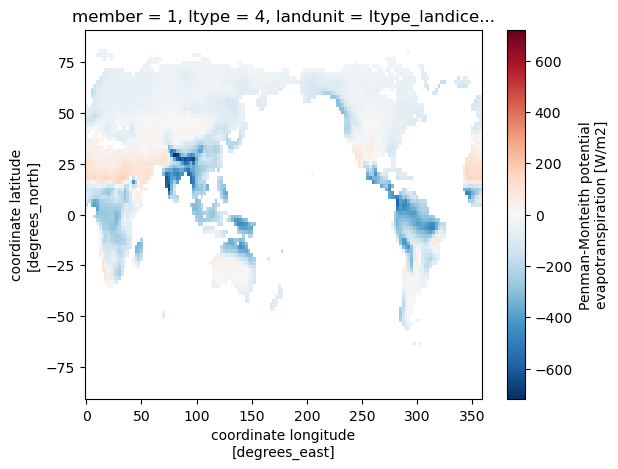

In [183]:
(pet_clim_month - prec_clim_month).where(pet_clim_month > 0).min(dim='month').sel(member=1).plot()

In [158]:
nmon = 3

min_pet_center_month = clim_min_month(pet_clim_month, n_month=nmon).compute()
max_pet_center_month = clim_max_month(pet_clim_month, n_month=nmon).compute()

min_prec_center_month = clim_min_month(prec_clim_month, n_month=nmon).compute()
max_prec_center_month = clim_max_month(prec_clim_month, n_month=nmon).compute()

/glade/work/bbuchovecky/miniforge3/envs/data-sci-py312/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 683.49 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/glade/work/bbuchovecky/miniforge3/envs/data-sci-py312/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 683.49 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


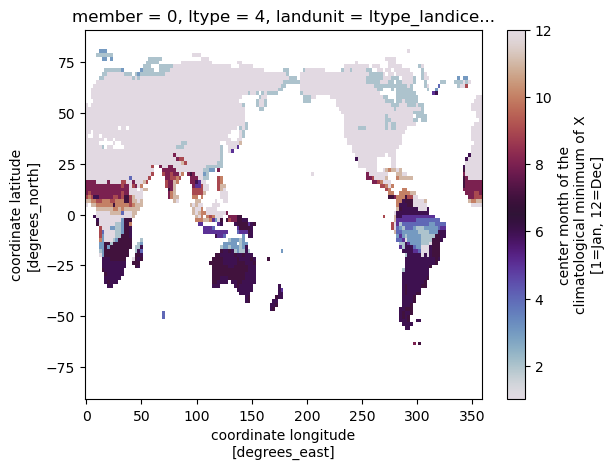

In [159]:
min_pet_center_month.where(all_mask).sel(member=0).plot(cmap='twilight')

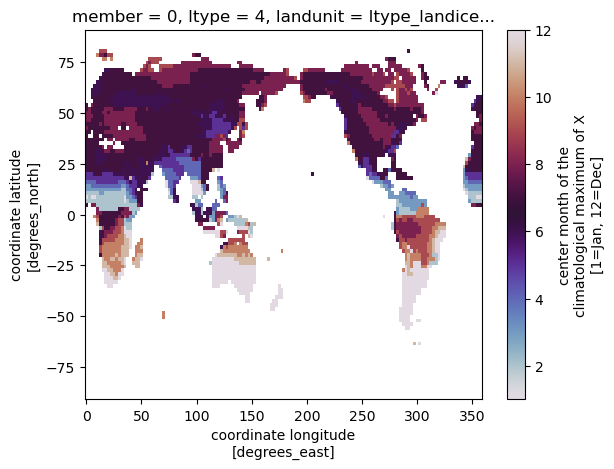

In [160]:
max_pet_center_month.where(all_mask).sel(member=0).plot(cmap='twilight')

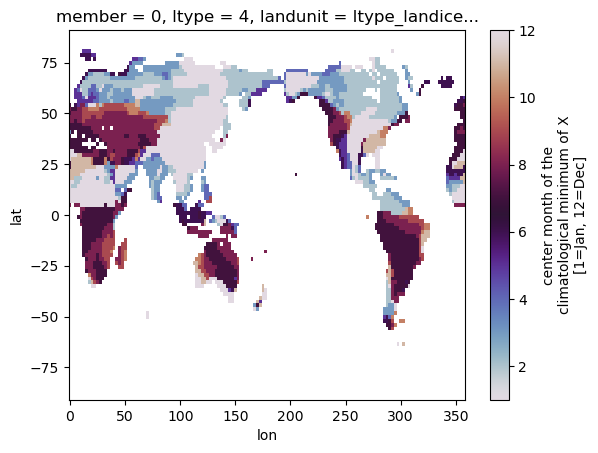

In [161]:
min_prec_center_month.where(all_mask).sel(member=0).plot(cmap='twilight')

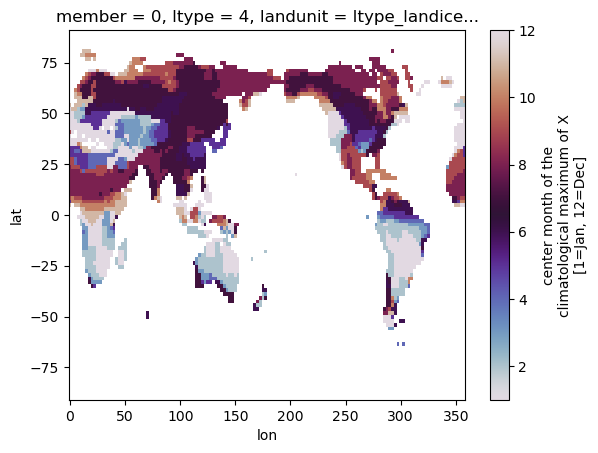

In [162]:
max_prec_center_month.where(all_mask).sel(member=0).plot(cmap='twilight')

In [163]:
nmon = 3

arid_center_month = clim_min_month(ai_clim_month, n_month=nmon).compute()
arid_subset_lai_mean = clim_subset_mean(fhist_masked['TLAI_month_1'], arid_center_month, n_month=nmon)
arid_subset_ai_mean = clim_subset_mean(ai, arid_center_month, n_month=nmon)

humid_center_month = clim_max_month(ai_clim_month, n_month=nmon).compute()
humid_subset_lai_mean = clim_subset_mean(fhist_masked['TLAI_month_1'], humid_center_month, n_month=nmon)
humid_subset_ai_mean = clim_subset_mean(ai, humid_center_month, n_month=nmon)

delta_arid_center_month = distance_between_cyclic_points(
    arid_center_month.sel(member=slice(1, None)),
    arid_center_month.sel(member=0),
    12,
).compute()
clim_abs_amp = climatology_abs_amplitude(ai_clim_month).compute()
clim_frac_amp = climatological_frac_amplitude(ai_clim_month).compute()

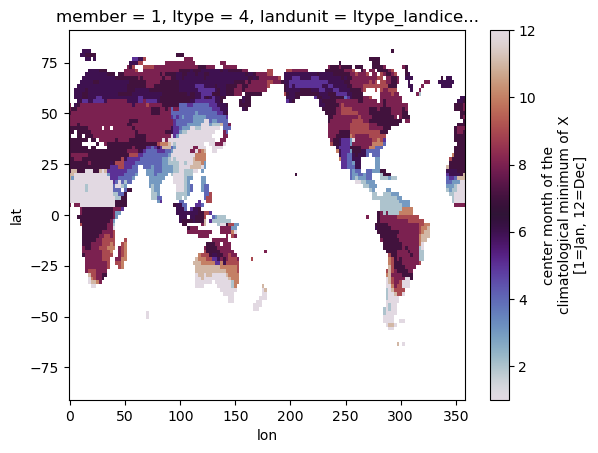

In [164]:
arid_center_month.where(all_mask).sel(member=1).plot(cmap='twilight')

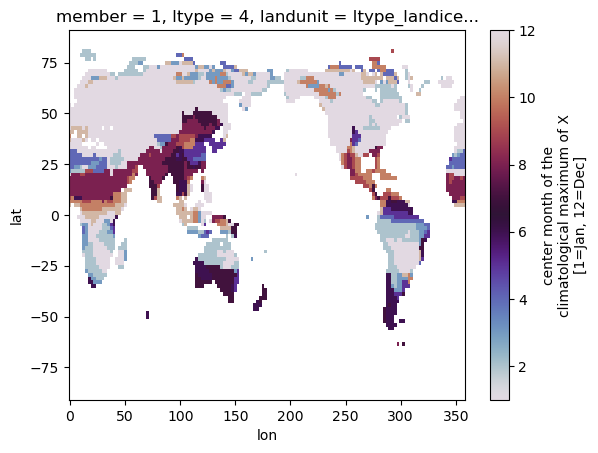

In [165]:
humid_center_month.where(all_mask).sel(member=1).plot(cmap='twilight')

In [ ]:
# delta_arid_center_month.where(all_mask).plot(col='member', col_wrap=6, cmap='twilight')

Text(0.5, 1.015, 'difference in clim max month between members and 0')

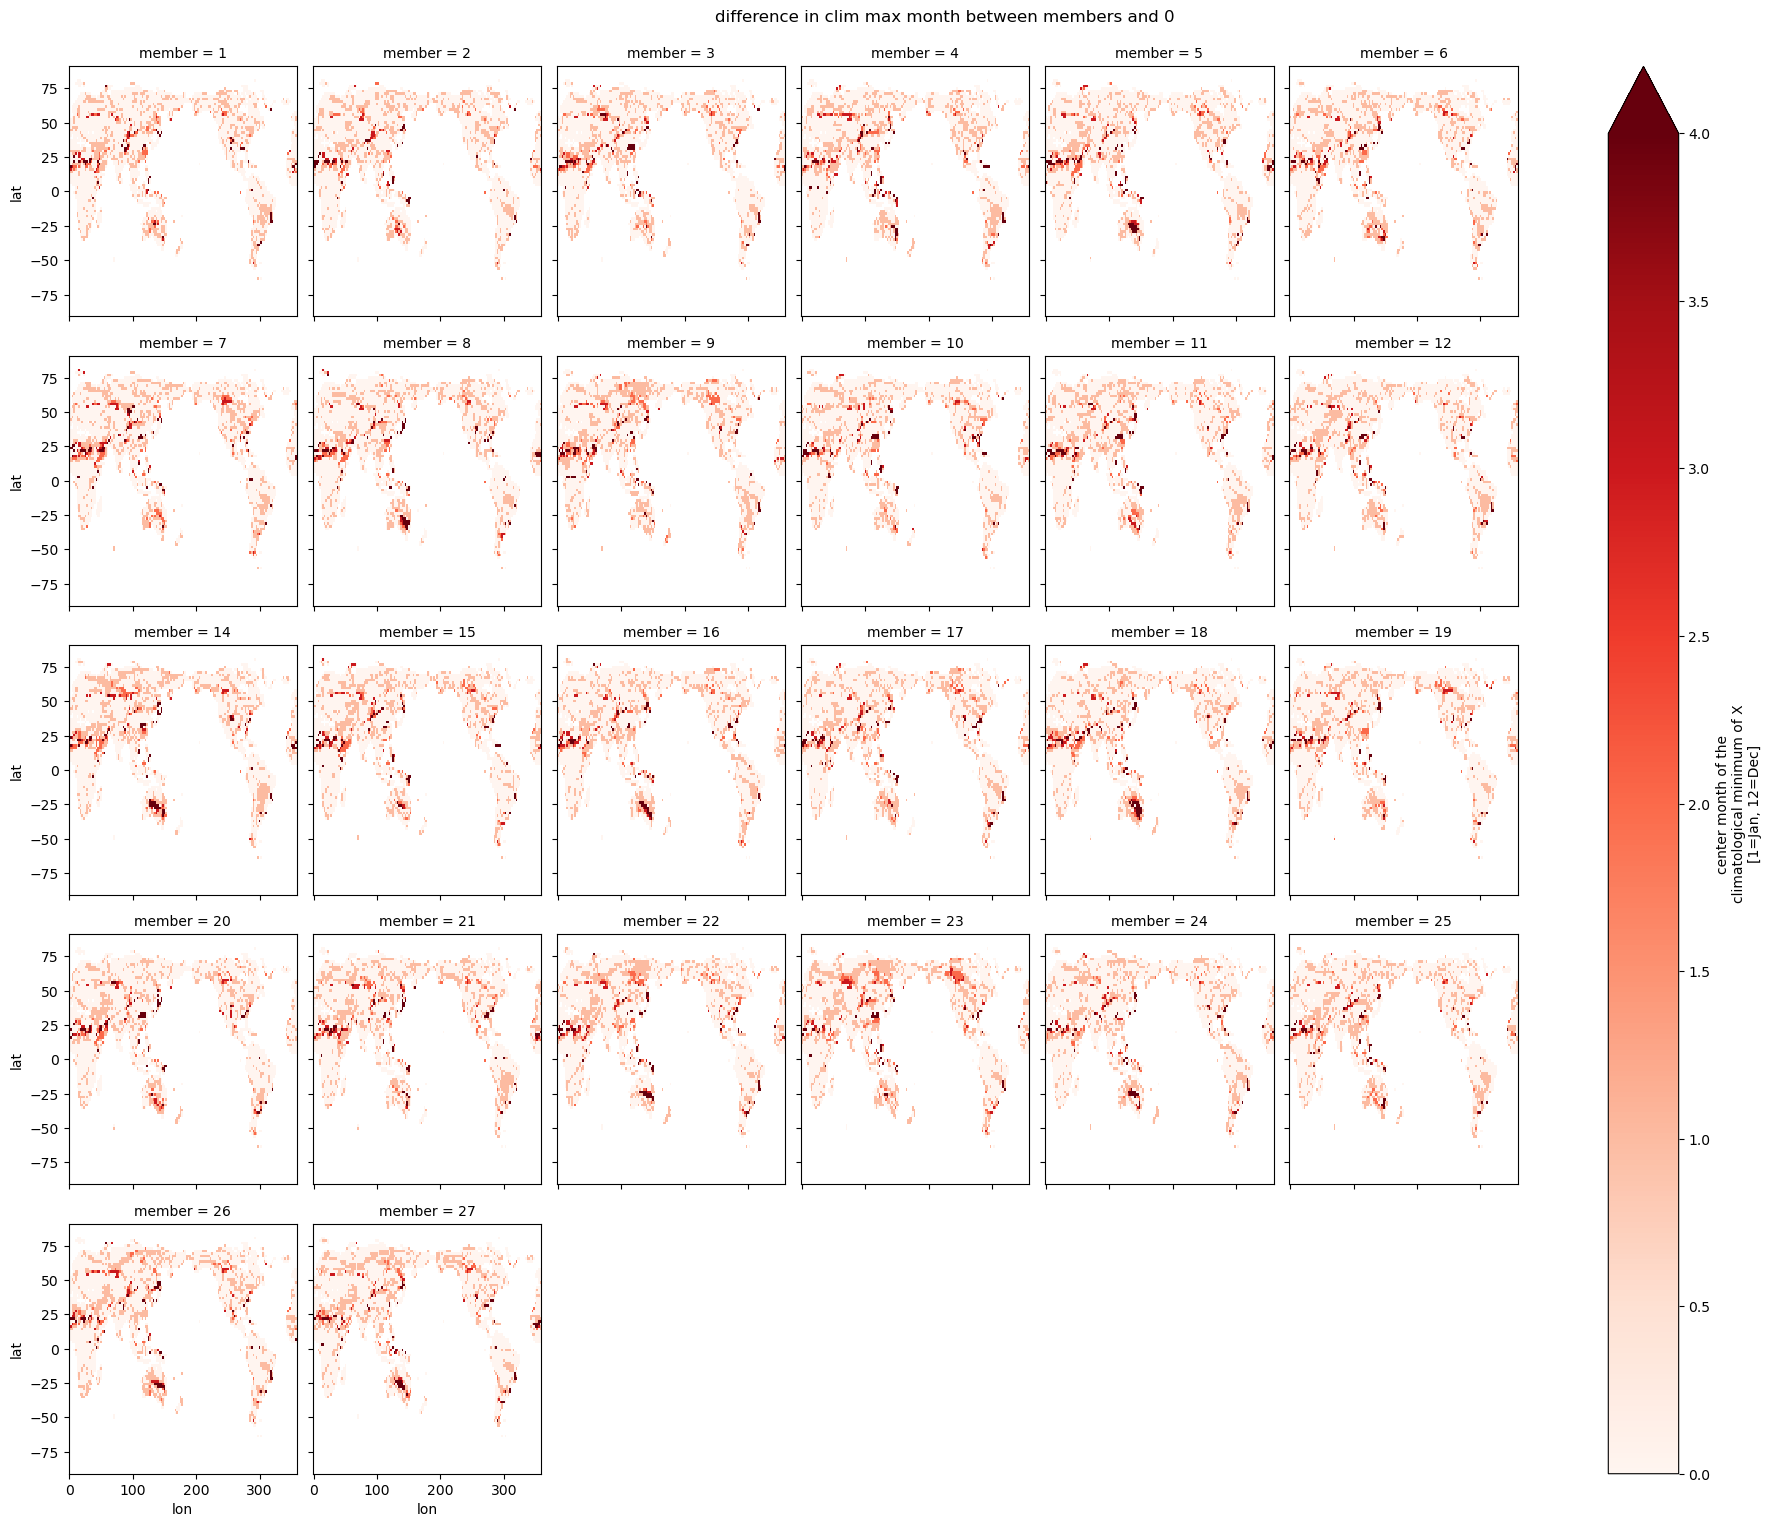

In [167]:
fg = delta_arid_center_month.where(all_mask).plot(col='member', vmin=0, vmax=4, col_wrap=6, cmap='Reds')
fg.fig.suptitle('difference in clim max month between members and 0', y=1.015)

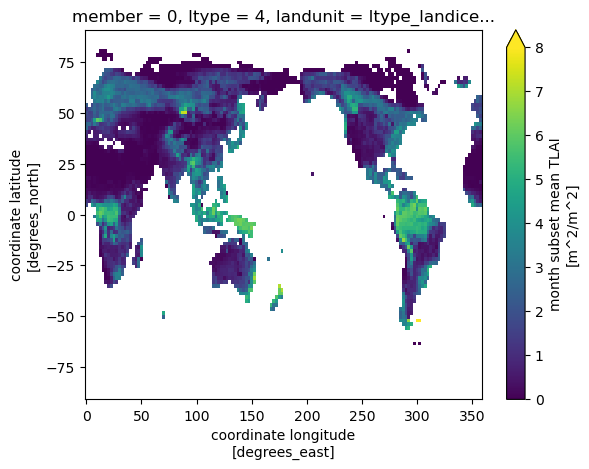

In [168]:
arid_subset_lai_mean.mean(dim='year').sel(member=0).plot(vmax=8)

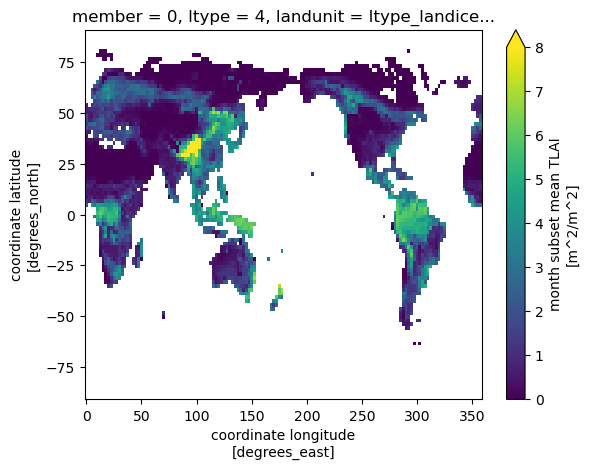

In [169]:
humid_subset_lai_mean.mean(dim='year').sel(member=0).plot(vmax=8)

In [171]:
humid_center_month.sel(lat=slice(24, 26), lon=slice(80, 82)).sel(member=0).values

array([[8]])

In [172]:
arid_center_month.sel(lat=slice(24, 26), lon=slice(80, 82)).sel(member=0).values

array([[3]])

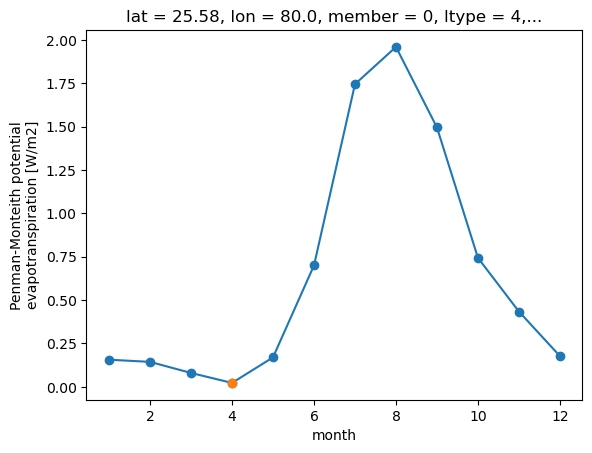

In [173]:
ai_clim_month.sel(lat=slice(24, 26), lon=slice(80, 82)).sel(member=0).plot(marker='o')
plt.plot(4, ai_clim_month.sel(lat=slice(24, 26), lon=slice(80, 82), month=4).sel(member=0).values, marker='o', c='tab:orange')

In [175]:
humid_center_month.sel(lat=slice(49,51), lon=slice(260, 262)).sel(member=0).values

array([[1]])

In [174]:
arid_center_month.sel(lat=slice(49,51), lon=slice(260, 262)).sel(member=0).values

array([[9]])

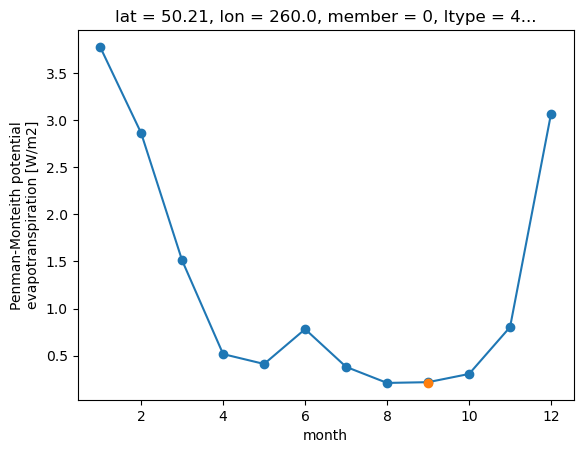

In [177]:
ai_clim_month.sel(lat=slice(49,51), lon=slice(260, 262)).sel(member=0).plot(marker='o')
plt.plot(9, ai_clim_month.sel(lat=slice(49,51), lon=slice(260, 262), month=8).sel(member=0).values, marker='o', c='tab:orange')

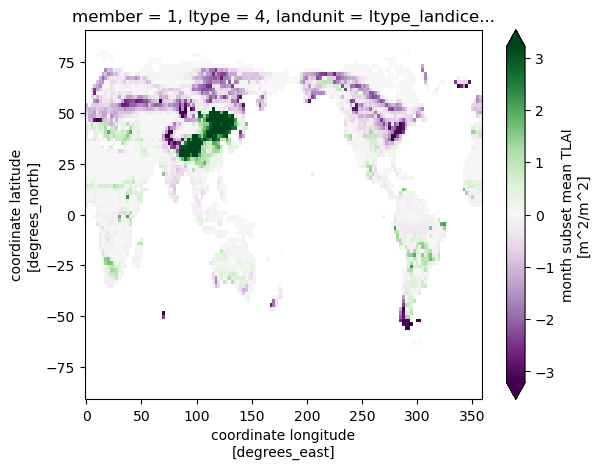

In [179]:
(humid_subset_lai_mean.mean(dim='year').sel(member=1) - arid_subset_lai_mean.mean(dim='year').sel(member=1)).plot(robust=True, cmap='PRGn')

# Compute bin means

In [8]:
target = fhist_masked['ET_month_1'].sel(member=slice(1, None)) - fhist_masked['ET_month_1'].sel(member=0)
x_var = fhist_masked['AI_clim'].sel(member=slice(1, None)).expand_dims(time=target.time)
y_var = fhist_masked['TLAI_month_1'].sel(member=slice(1, None))

lai_ai_bin_stats = compute_2d_bin_stats(
    target, y_var, x_var, member_dim='member',
    collapse_duplicate_quantile_bins=False,
    pool_edges_across_ensemble=True,
)

/glade/work/bbuchovecky/miniforge3/envs/data-sci-py312/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 1.29 GiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


# Create significance mask

In [9]:
import scipy.stats as stats

alpha = 0.05
n_min = 10

means = lai_ai_bin_stats.sel(stats='mean')
stds = np.sqrt(lai_ai_bin_stats.sel(stats='var_samp'))
ns = lai_ai_bin_stats.sel(stats='count')

# Calculate t-statistic and critical value
t_critical = stats.t.ppf(1 - alpha / 2, ns - 1)
t_statistic = means / (stds / np.sqrt(ns))

# Perform significance test
significant = (np.abs(t_statistic) > t_critical) & (lai_ai_bin_stats.sel(stats='count') > n_min)

# Plot

In [9]:
# fg = lai_ai_bin_stats.sel(stats='mean').where(significant).plot(
#     col='member',
#     col_wrap=6,
#     vmin=-8, vmax=8, cmap='BrBG',
#     cbar_kwargs={'label': '$\\Delta$ ET [W m$^{-2}$]', 'orientation': 'horizontal', 'pad': 0.1, 'fraction': 0.025}
# ) # type: ignore[reportGeneralTypeIssues]

# ax = fg.axs.ravel()
# for i, m in enumerate(lai_ai_bin_stats.member.values):
#     ax[i].set_title(xclim.ppe.get_member_name(m), color=xclim.ppe.get_member_cat_color(m), fontweight='bold')

# for j in range(2):
#     fg.axs[-1, j].set_xlabel('Aridity Quantile $\\rightarrow$', fontsize=16, fontweight='bold')

# for i in range(5):
#     fg.axs[i, 0].set_ylabel('LAI Quantile $\\rightarrow$', fontsize=16, fontweight='bold')

In [12]:
from matplotlib.patches import Patch
from matplotlib.patches import Circle

def plot_fhist_binned_mean(
    bm,
    jh,
    n_xy_bins,
    target_label,
    x_label,
    y_label,
    cmap,
    vmin,
    vmax,
    vabs=None,
    signif=None,
    add_circles=True,
    ref_count=None,
    **kwargs,
):
    """
    Create a multi-panel binned mean plot for FHIST ensemble members.

    Generates a figure with subplots (6 columns x 5 rows) showing binned mean values
    for each ensemble member, with overlaid circles representing sample sizes. The color
    intensity indicates the magnitude of the binned mean, while circle size and linewidth
    represent the sample count in each bin.

    Parameters
    ----------
    bm : xarray.DataArray
        Binned mean values with dimensions including 'member', 'ibx', and 'iby'.
    jh : xarray.DataArray
        Sample count (joint histogram) data with dimensions including 'member', 'ibx', and 'iby'.
    n_xy_bins : int
        Number of bins along each axis. Used to set tick positions and labels.
    target_name : str
        Name of the variable being shaded. Used for labeling.
    x_var : str
        Name of the variable on the x-axis. Used for labeling.
    y_var : str
        Name of the variable on the y-axis. Used for labeling.
    cmap : str
        Colormap for the plot.
    vmin, vmax : float
        Define the data range that the colormap covers.
    vabs : float, optional
        If provided, centers the colormap range around zero and sets vmin=-vabs, vmax=vabs.
    signif : dict, optional
        Dictionary containing the keys 'alpha' and 'n_min'. If provided, adds annotation under the
        colorbar describing statistical significance.
        -> alpha : float
            Significance level (critical alpha value) for the statistical test.
        -> n_min : int
            Minimum sample size threshold for significance.
    add_circles : bool, optional
        Add circles with radii that correspond to the bin sample size.
    ref_count : int, optional
        Reference count for the scale circles.

    Returns
    -------
    matplotlib.figure.Figure
        Figure object containing the multi-panel plot with colorbar, legend, and
        reference circle scale.
    matplotlib.axes.Axes
        Ndarray of axes objects for each subplot.

    Notes
    -----
    - Circle size and linewidth are scaled using a power law (scaling_power=0.4) to
      amplify visibility of bins with smaller sample sizes.
    - A reference scale of circles is displayed showing sample sizes at 25%, 50%, and 100%
      of the maximum sample count in the data.
    - Empty subplots (beyond the number of ensemble members) are removed.
    """

    bm = bm.compute()
    jh = jh.compute()

    if vabs is not None:
        vmin = -vabs
        vmax = vabs

    scaling_power = 0.4  # use power scaling to draw out bins with lower sample size
    ref_count = ref_count if ref_count is not None else round(jh.max().values.item() / 1e2, 0) * 1e2
    radius_scalar = 0.4
    lw_scalar = 0.3
    line_alpha = 0.5

    ncols = 6
    nrows = 5

    fig, axs = plt.subplots(
        ncols=ncols,
        nrows=nrows,
        sharex=True,
        sharey=True,
        figsize=(14, 13),
        subplot_kw=dict(box_aspect=1),
        constrained_layout=True,
        **kwargs
    )
    ax = axs.flatten()

    pcm = None
    for i, m in enumerate(bm.member.values):
        pcm = ax[i].pcolormesh(
            bm.sel(member=m), shading="auto", cmap=cmap, vmin=vmin, vmax=vmax
        )

        if add_circles:
            m_jh = jh.sel(member=m).T
            for ii in range(len(jh.x_bin)):
                for jj in range(len(jh.y_bin)):
                    count = m_jh.values[ii, jj]
                    if count > 0:
                        radius = radius_scalar * ((count / ref_count) ** scaling_power)
                        lw = lw_scalar + ((count / ref_count) ** scaling_power)
                        circle = Circle(
                            (ii + 0.5, jj + 0.5),
                            radius,
                            fill=False,
                            edgecolor="black",
                            linewidth=lw,
                            alpha=line_alpha,
                        )
                        ax[i].add_patch(circle)

        ax[i].set_title(
            xclim.ppe.get_member_name(m),
            color=xclim.ppe.get_member_cat_color(m),
            # color="k",
            fontsize=10,
            fontweight="bold",
            loc="center",
        )
        ax[i].set_xlim(0, len(bm.x_bin))
        ax[i].set_ylim(0, len(bm.y_bin))

        ax[i].set_yticks(np.arange(n_xy_bins) + 0.5)
        ax[i].set_xticks(np.arange(n_xy_bins) + 0.5)
        ax[i].tick_params(length=0)  # remove tick marks

        # Add 'low' and 'high' labels to the axes
        ticklabels = np.full((n_xy_bins), "", dtype=object)
        # ticklabels[0] = "low"
        # ticklabels[-1] = "high"

        ax[i].set_yticklabels(ticklabels, rotation=35, ha="right", va="center")
        ax[i].set_xticklabels(ticklabels, rotation=35, ha="center", va="top")

        if i % ncols == 0:
            ax[i].set_ylabel(f"{y_label}", fontsize=14)
        if i // ncols == nrows - 1:
            ax[i].set_xlabel(f"{x_label}", fontsize=14)

        # Color the outer edge of the subplot corresponding to the parameter functional category
        # for spine in ax[i].spines.values():
        #     spine.set_color(xclim.ppe.get_member_cat_color(m))
        #     spine.set_linewidth(4)

    # Add colorbar below all subplots
    if vmin == 0:
        extend = "max"
    else:
        extend = "both"
    cbar = fig.colorbar(
        pcm,
        ax=axs,
        orientation="horizontal",
        extend=extend,
        fraction=0.025,
        shrink=0.9,
        pad=0.025,
    )
    cbar.set_label(target_label, fontsize=14)
    cbar.ax.tick_params(labelsize=12)

    for i in range(len(bm.member), ncols * nrows):
        ax[i].remove()

    # Create custom legend for member categories
    # Get unique categories and their colors
    categories = {}
    for m in bm.member.values:
        cat = xclim.ppe.get_member_cat_name(m)
        color = xclim.ppe.get_member_cat_color(m)
        if cat not in categories:
            categories[cat] = color

    # Create legend handles
    legend_handles = [
        Patch(facecolor=color, label=cat) for cat, color in categories.items()
    ]

    # Add legend using figure coordinates
    fig.legend(
        handles=legend_handles,
        ncols=3,
        loc="lower right",
        bbox_to_anchor=(0.98, 0.15),
        bbox_transform=fig.transFigure,
        frameon=True,
        fontsize=12,
        title="Functional Categories",
        title_fontproperties={
            "weight": "bold",
            "size": 12,
        },
    )

    # Draw the figure to apply and fix layout
    fig.canvas.draw()

    # Get colorbar position
    cbar_pos = cbar.ax.get_position()

    if signif is not None:
        # Add text below legend for alpha and n_min parameters
        alpha = signif.get('alpha', 'alpha')
        n_min = signif.get('n_min', 'n_min')
        fig.text(
            (cbar_pos.x0 + cbar_pos.x1) / 2,
            cbar_pos.y0 - 0.05,
            f"$Significance$: $two$-$sided$ $t$-$test$ $\\alpha = {alpha}$, $n \\geq {n_min}$",
            ha="center",
            va="top",
            fontsize=10,
            transform=fig.transFigure,
        )

    if add_circles:
        # Create three reference circles of different sizes
        scale_counts = [ref_count * 0.25, ref_count * 0.5, ref_count]

        # Position for the scale circles
        scale_x = cbar_pos.x1 + 0.05
        scale_y_base = (cbar_pos.y0 + cbar_pos.y1) / 2

        # Calculate spacing
        max_radius_data = radius_scalar * ((scale_counts[-1] / ref_count) ** scaling_power)
        point_data = np.array([[0, 0], [max_radius_data, 0]])
        point_display = ax[0].transData.transform(point_data)
        point_figure = fig.transFigure.inverted().transform(point_display)
        max_radius_fig = np.linalg.norm(point_figure[1] - point_figure[0])

        spacing = max_radius_fig * 2.5

        for idx, scale_count in enumerate(scale_counts):
            # Calculate radius with same scaling
            data_radius = radius_scalar * ((scale_count / ref_count) ** scaling_power)
            scale_lw = lw_scalar + ((scale_count / ref_count) ** scaling_power)

            # Convert to figure coordinates
            point_data = np.array([[0, 0], [data_radius, 0]])
            point_display = ax[0].transData.transform(point_data)
            point_figure = fig.transFigure.inverted().transform(point_display)
            scale_radius = np.linalg.norm(point_figure[1] - point_figure[0])

            # Position circles vertically with spacing
            scale_y = scale_y_base + (idx - 1) * spacing

            scale_circle = Circle(
                (scale_x, scale_y),
                scale_radius,
                fill=False,
                edgecolor="black",
                linewidth=scale_lw,
                alpha=0.6,
                clip_on=False,
                transform=fig.transFigure,
            )
            fig.add_artist(scale_circle)

            fig.text(
                scale_x + max_radius_fig + 0.01,
                scale_y,
                f"{int(scale_count):,d}",
                ha="left",
                va="center",
                fontsize=9,
                transform=fig.transFigure,
            )

        # Add label above reference circles
        fig.text(
            scale_x - max_radius_fig,
            scale_y_base + idx * spacing + 0.005,
            "Bin sample size:",
            ha="left",
            va="center",
            fontsize=9,
            transform=fig.transFigure,
        )

    return fig, axs

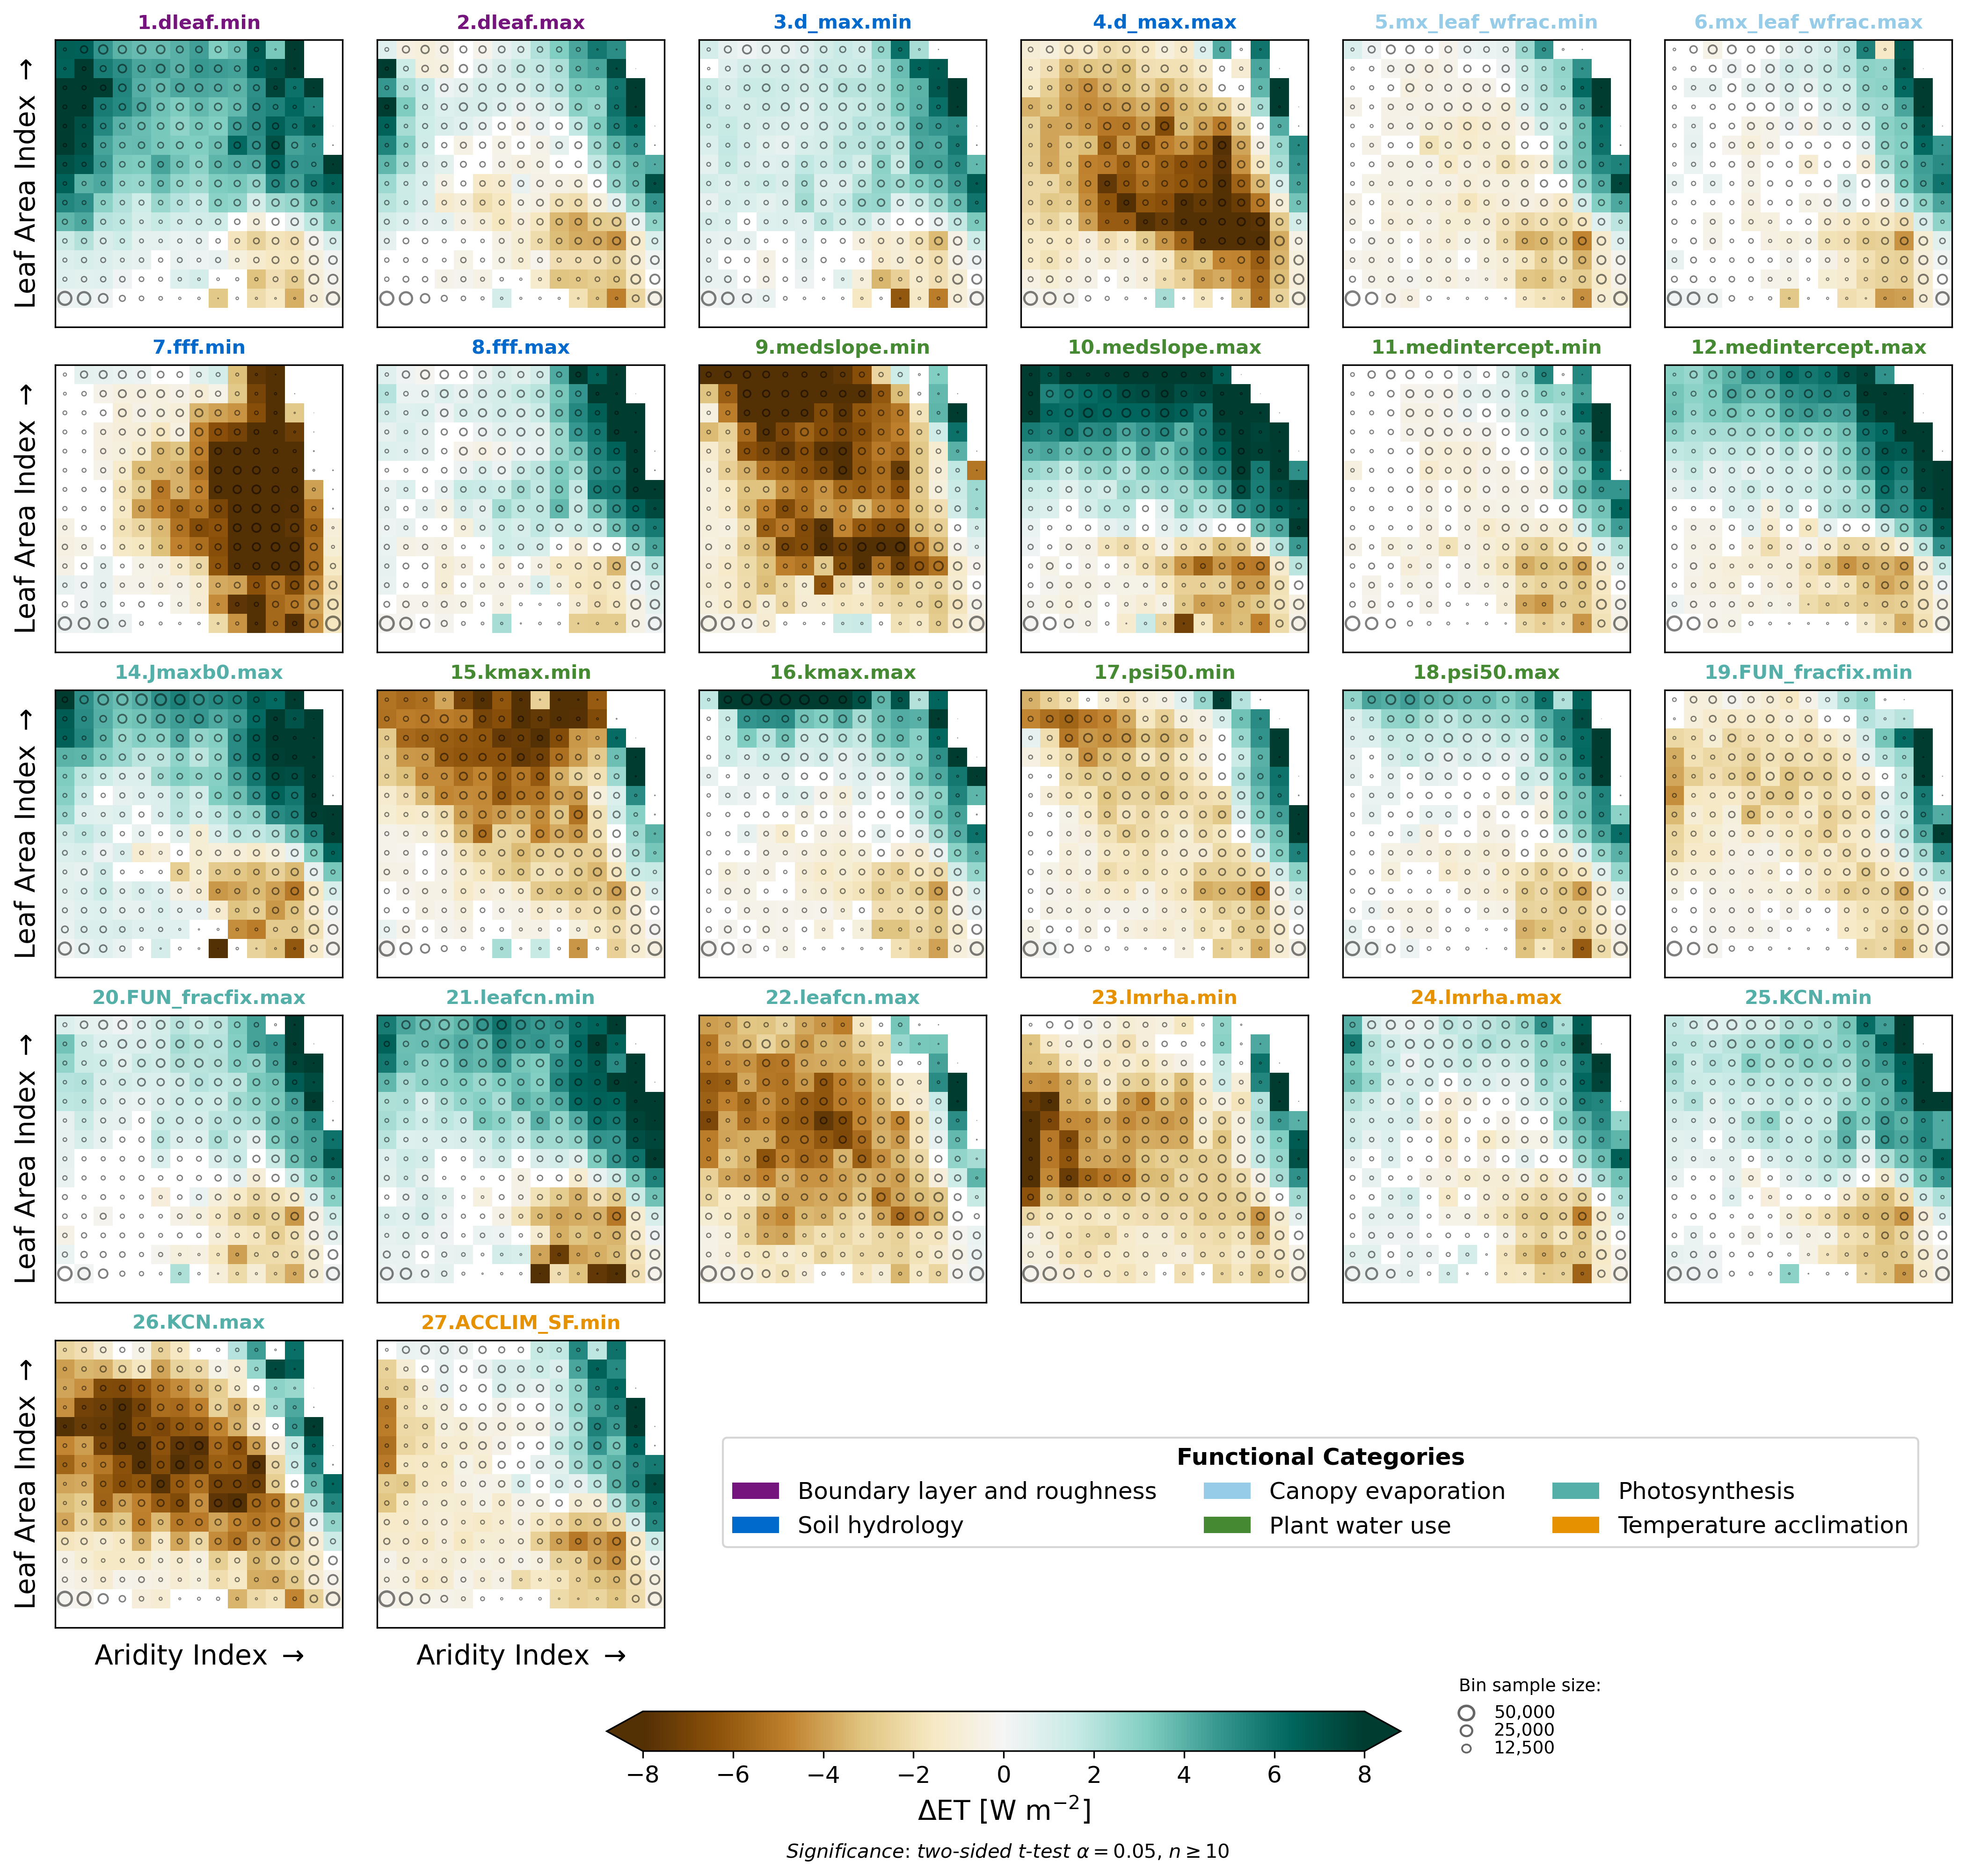

In [11]:
fig, axs = plot_fhist_binned_mean(
    bm=lai_ai_bin_stats.sel(stats='mean').where(significant),
    jh=lai_ai_bin_stats.sel(stats='count'),
    n_xy_bins=15,
    target_label='$\\Delta$ET [W m$^{-2}$]',
    x_label='Aridity Index $\\rightarrow$',
    y_label='Leaf Area Index $\\rightarrow$',
    cmap='BrBG',
    vmin=-8,
    vmax=8,
    signif={'alpha': alpha, 'n_min': n_min},
    add_circles=True,
    ref_count=50_000,
    dpi=300,
)

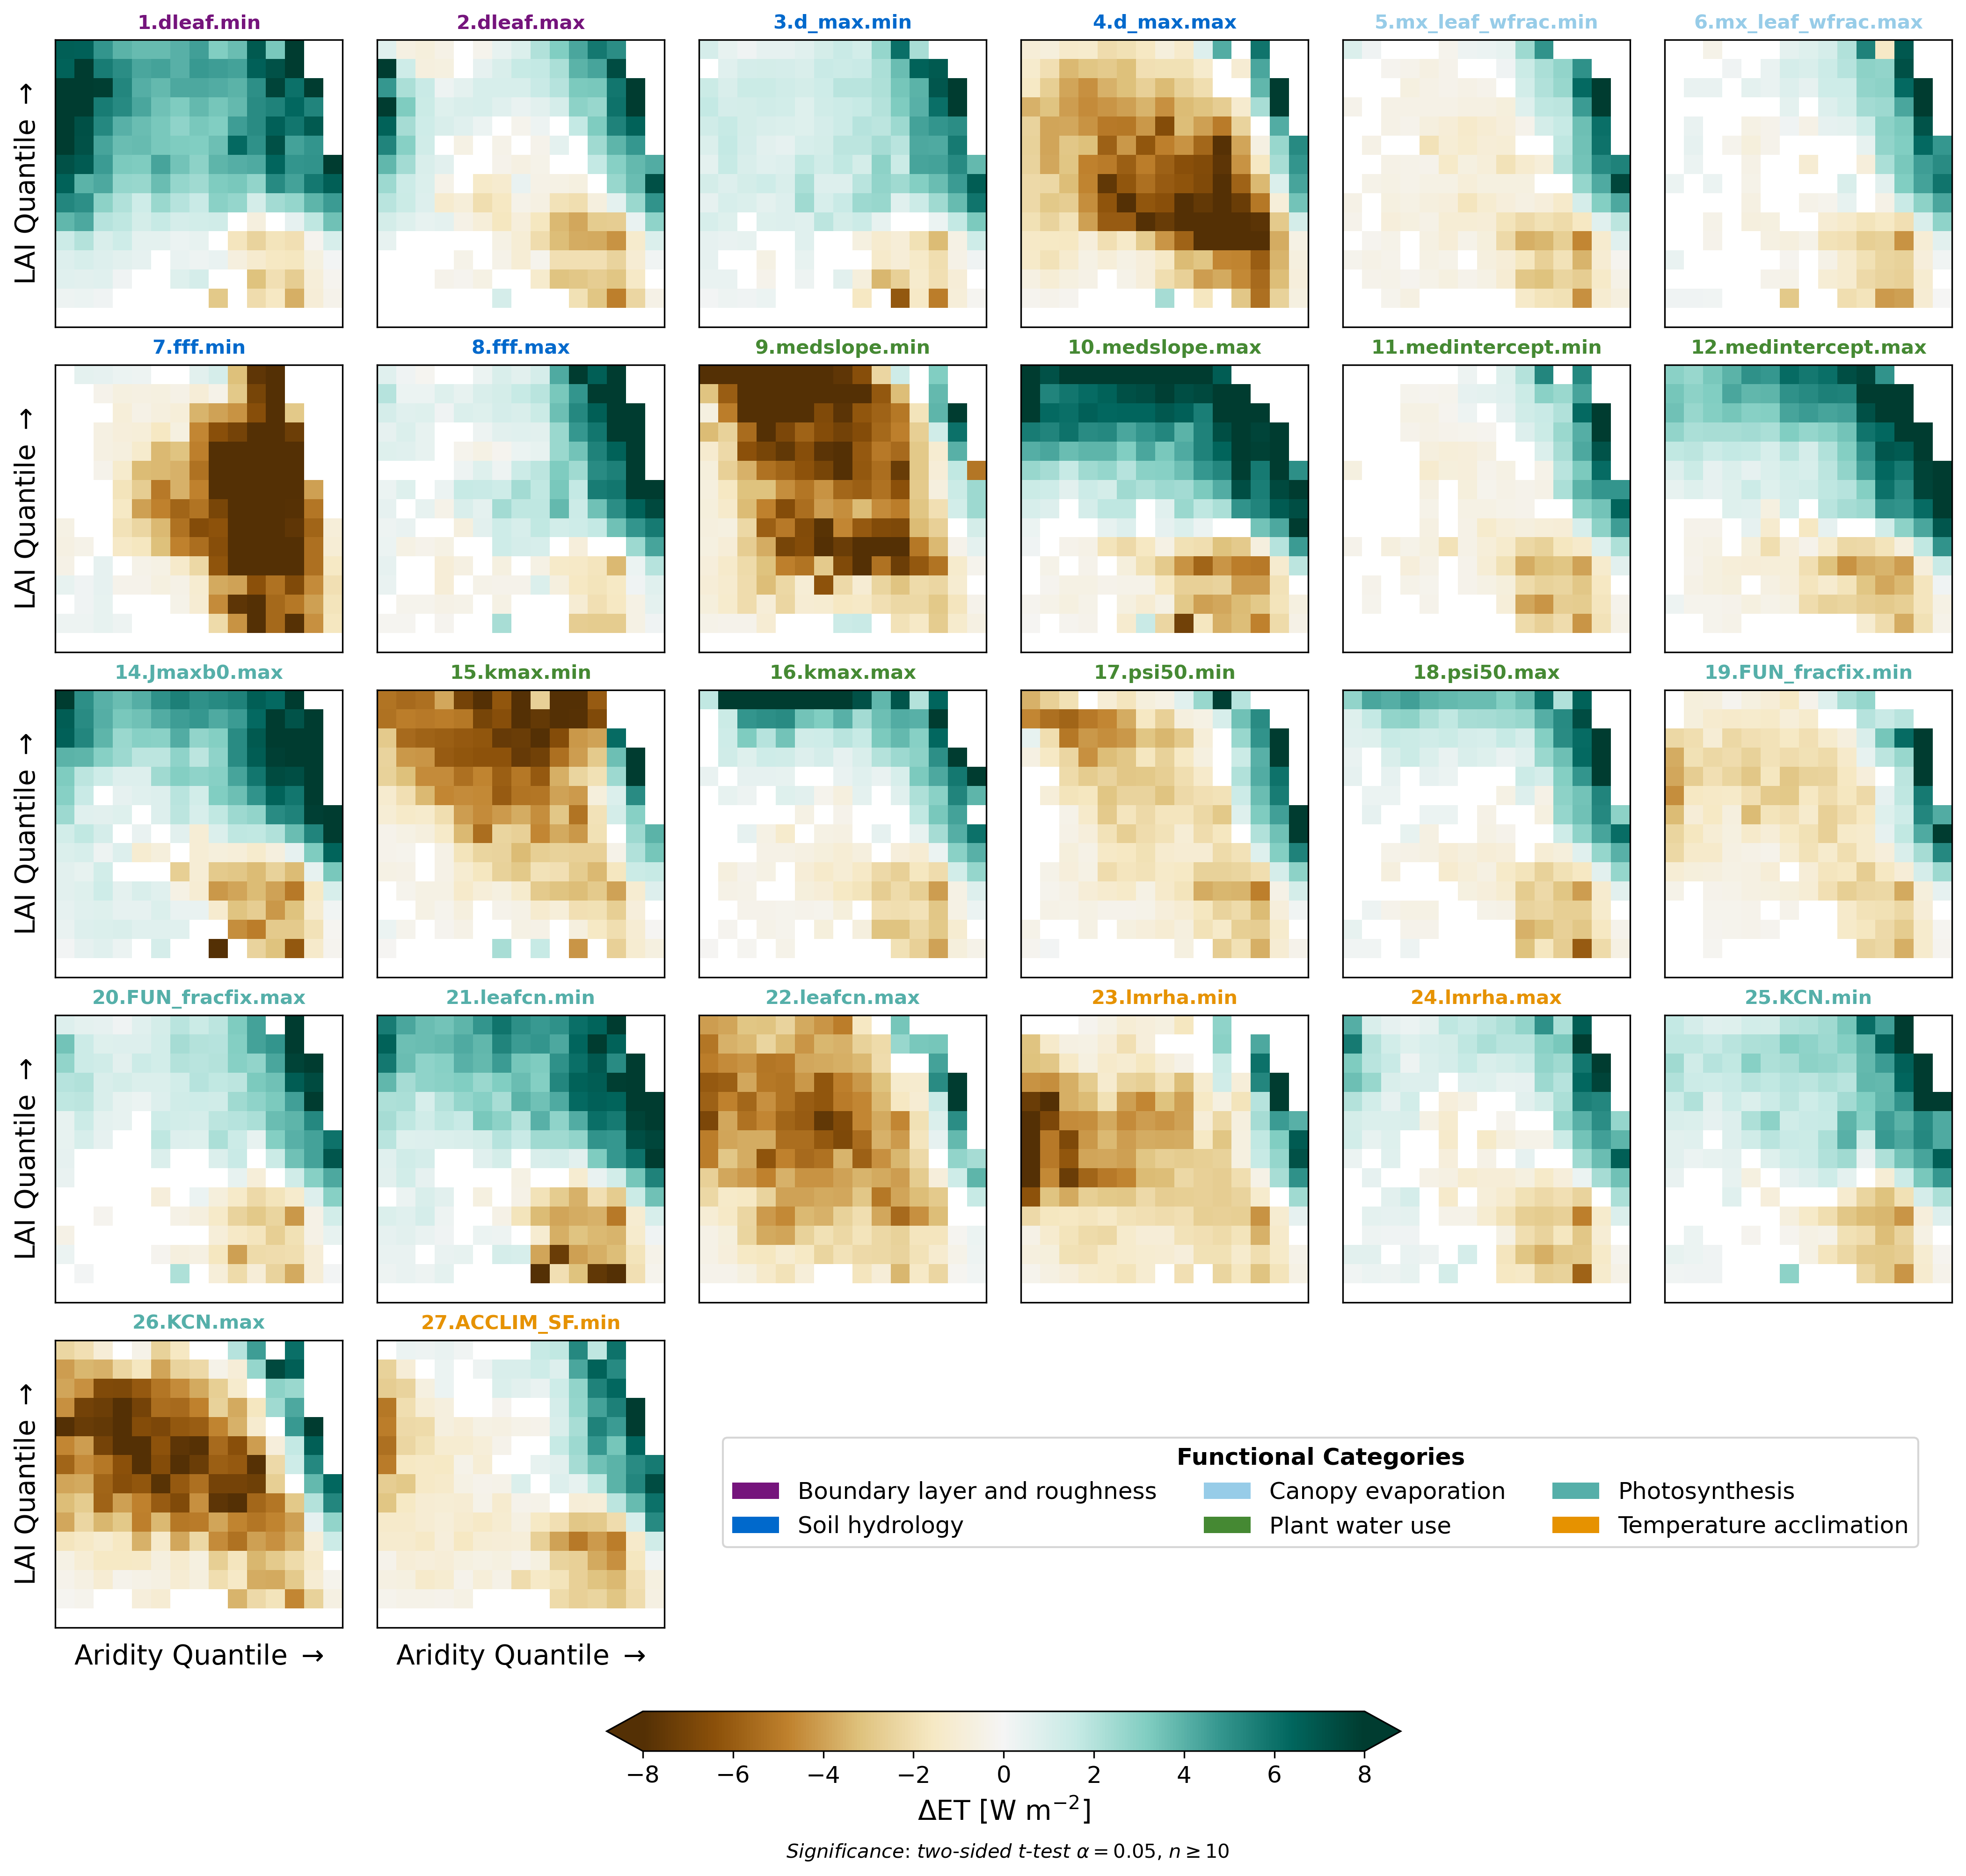

In [14]:
fig, axs = plot_fhist_binned_mean(
    bm=lai_ai_bin_stats.sel(stats='mean').where(significant),
    jh=lai_ai_bin_stats.sel(stats='count'),
    n_xy_bins=15,
    target_label='$\\Delta$ET [W m$^{-2}$]',
    x_label='Aridity Quantile $\\rightarrow$',
    y_label='LAI Quantile $\\rightarrow$',
    cmap='BrBG',
    vmin=-8,
    vmax=8,
    signif={'alpha': alpha, 'n_min': n_min},
    add_circles=False,
    dpi=300,
)

fig.savefig("fig/for/abby/full_ens.lai_aridity_bin_det_mean.pooled_bins.1995-2014.png")

In [ ]:
def split_years_months(da):
    assert 'time' in da.dims, ValueError("da must have a time coordinate")
    assert da.time.size % 12 == 0, ValueError("time coordinate must be a multiple of 12")

    name = da.name
    years  = np.unique(da.time.dt.year.values)
    months = np.unique(da.time.dt.month.values)
    
    # Rechunk time dim contiguously before reshape
    da = da.chunk({'time': -1})
    
    new_shape = (len(years), len(months)) + da.shape[1:]
    new_dims  = ['year', 'month'] + list(da.dims[1:])

    extra_coords = {k: v for k, v in da.coords.items()
                    if 'time' not in v.dims}
    
    return xr.DataArray(
        da.data.reshape(new_shape),   # dask-safe
        dims=new_dims,
        coords={'year': years, 'month': months, **extra_coords}
    ).rename(name)


def combine_years_months(da, freq='MS'):
    name = da.name
    years  = da.year.values   # shape (Y,)
    months = da.month.values  # shape (M,)

    # Build full Y×M time index, then flatten
    yy, mm = np.meshgrid(years, months, indexing='ij')  # both (Y, M)
    time_index = xr.date_range(                         # or pd.date_range if using numpy datetimes
        start=f'{years[0]}-{months[0]:02d}',
        periods=len(years) * len(months),
        freq=freq,
        use_cftime=True
    )

    # Flatten year×month into time, preserve trailing spatial dims
    trailing_dims   = list(da.dims[2:])          # e.g. ['lat', 'lon']
    trailing_shape  = da.shape[2:]
    flat_data = da.data.reshape(len(time_index), *trailing_shape)  # dask-safe

    # Preserve non-(year,month) coords
    extra_coords = {k: v for k, v in da.coords.items()
                    if not any(d in ('year', 'month') for d in v.dims)}

    return xr.DataArray(
        flat_data,
        dims=['time'] + trailing_dims,
        coords={'time': time_index, **extra_coords}
    ).rename(name)

In [ ]:
x = split_years_months(fhist_masked['TLAI_month_1'].sel(member=1))

In [ ]:
x_yr_mean = x.mean(dim='year')
x_yr_sorted = xr.apply_ufunc(
    np.sort,
    x_yr_mean,
    input_core_dims=[["month"]],
    output_core_dims=[["month"]],
    vectorize=True,
    dask="parallelized",
    output_dtypes=[x_yr_mean.dtype],
).rename({"month": "rank"})

x_yr_sorted = x_yr_sorted.assign_coords(rank=np.arange(1, x_yr_sorted.sizes["rank"] + 1))

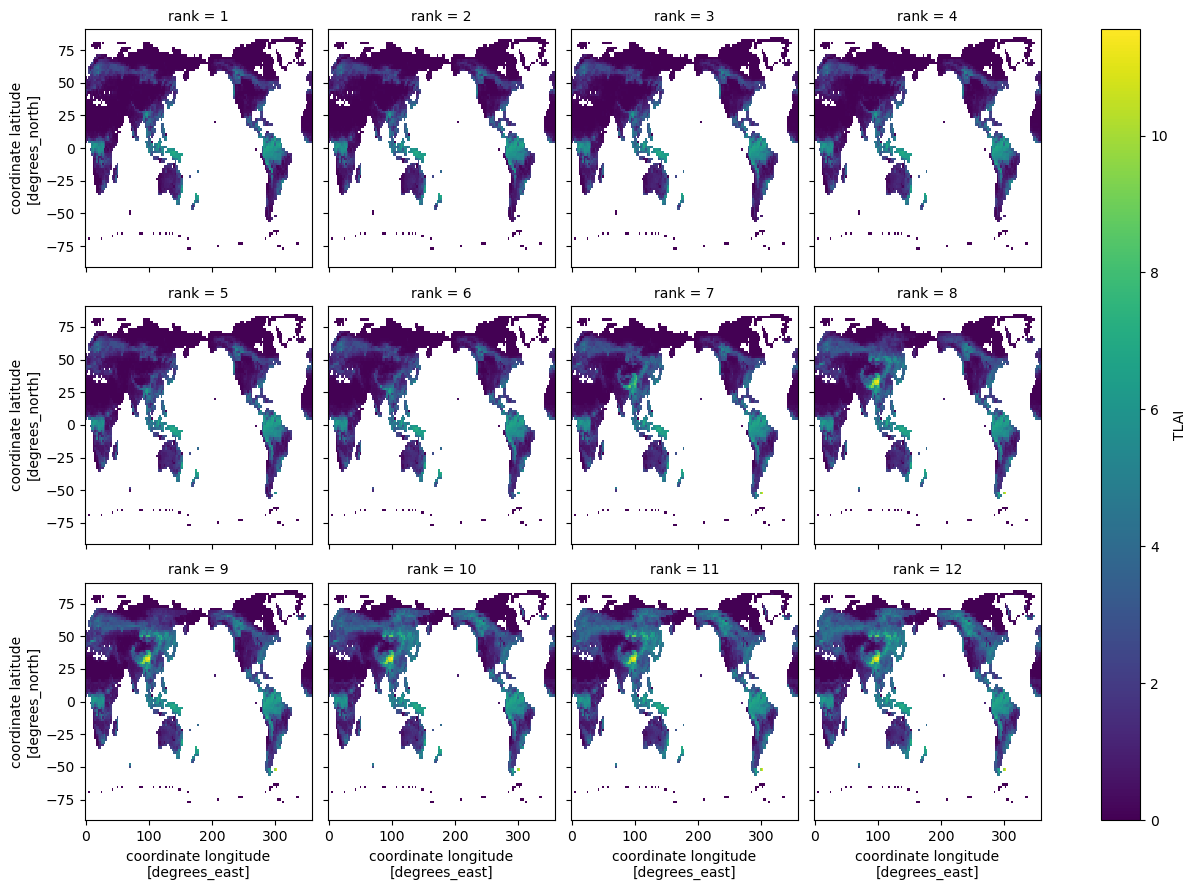

In [ ]:
x_yr_sorted.plot(col='rank', col_wrap=4)